# Lab 8 – Principal Component Analysis (PCA)
**Big Data Techniques · "Gheorghe Asachi" Technical University of Iași**

This notebook covers all three exercises from Lab 8:
1. Covariance matrix of student grades (manual calculation)
2. PCA on 2D data points from `datapoints.txt` → find & plot principal components, then project + inverse-project
3. Evaluate quality of the projection using the coefficient of determination R²

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

---
## Exercise 1 – Covariance Matrix of Student Grades

We have 5 students and 3 exam grades each: **Math, Physics, Chemistry**.

The covariance matrix formula is:
$$\text{Cov}(A,B) = \frac{\sum_i (a_i - \bar{a})(b_i - \bar{b})}{N}$$

The diagonal of the covariance matrix contains the **variances** of each exam,
and the off-diagonal entries are the **covariances** between pairs of exams.

In [2]:
# ── Grade data ──────────────────────────────────────────────────────────────
# Each row is one student; columns are Math, Physics, Chemistry
grades = np.array([
    [9, 6, 9],   # Student 1
    [9, 9, 3],   # Student 2
    [6, 6, 6],   # Student 3
    [6, 6, 9],   # Student 4
    [3, 3, 3],   # Student 5
], dtype=float)

subjects = ['Math', 'Physics', 'Chemistry']
N = grades.shape[0]          # number of students (data points)
D = grades.shape[1]          # number of attributes (dimensions)
print(f"Dataset: {N} students, {D} exams")

Dataset: 5 students, 3 exams


In [3]:
# ── Step 1: compute the mean grade for each exam ────────────────────────────
means = np.mean(grades, axis=0)   # axis=0 → mean along the student dimension
print("Mean grades:", dict(zip(subjects, means)))

Mean grades: {'Math': np.float64(6.6), 'Physics': np.float64(6.0), 'Chemistry': np.float64(6.0)}


In [4]:
# ── Step 2: build the covariance matrix manually ────────────────────────────
# We subtract the mean from every value first ("center" the data)
centered = grades - means          # shape: (5, 3)

# The covariance matrix is (centered.T @ centered) / N
# Result is a 3×3 symmetric matrix
cov_matrix = (centered.T @ centered) / N

print("\nCovariance matrix (Math, Physics, Chemistry):")
print(np.round(cov_matrix, 4))


Covariance matrix (Math, Physics, Chemistry):
[[5.04 3.6  1.8 ]
 [3.6  3.6  0.  ]
 [1.8  0.   7.2 ]]


In [5]:
# ── Step 3: answer the questions ────────────────────────────────────────────

# Variances are on the main diagonal
variances = np.diag(cov_matrix)
print("Variances (diagonal):")
for subj, var in zip(subjects, variances):
    print(f"  {subj}: {var:.4f}")

print(f"\n→ Highest variance: {subjects[np.argmax(variances)]}")
print(f"→ Lowest  variance: {subjects[np.argmin(variances)]}")

# Covariances are the off-diagonal entries
print("\nCovariances (off-diagonal):")
for i in range(D):
    for j in range(i+1, D):
        cov = cov_matrix[i, j]
        direction = "positive (increase together)" if cov > 0 else \
                    "negative (inversely correlated)" if cov < 0 else \
                    "zero (uncorrelated)"
        print(f"  Cov({subjects[i]}, {subjects[j]}) = {cov:.4f}  →  {direction}")

Variances (diagonal):
  Math: 5.0400
  Physics: 3.6000
  Chemistry: 7.2000

→ Highest variance: Chemistry
→ Lowest  variance: Physics

Covariances (off-diagonal):
  Cov(Math, Physics) = 3.6000  →  positive (increase together)
  Cov(Math, Chemistry) = 1.8000  →  positive (increase together)
  Cov(Physics, Chemistry) = 0.0000  →  zero (uncorrelated)


---
## Exercise 2 – PCA on `datapoints.txt`

**Steps (as described in the lab):**
1. Load and plot the 2D data points
2. Compute the **covariance matrix** of the data
3. Find **eigenvalues & eigenvectors** of the covariance matrix
4. Sort eigenvectors by descending eigenvalue → these are the **principal components**
5. **Plot** the data + principal component arrows
6. **Project** each point onto the 1st principal component (2D → 1D)
7. **Inverse-project** back to 2D so the projected points can be visualised

In [6]:
# ── Upload datapoints.txt when running in Google Colab ──────────────────────
# Run this cell to upload the file from your computer.
# If you already placed the file in the same folder, you can skip this cell.
try:
    from google.colab import files
    print("Running in Colab – please upload datapoints.txt")
    uploaded = files.upload()   # a file picker dialog will appear
    DATA_FILE = 'datapoints.txt'
except ImportError:
    # Not in Colab – assume the file is in the current directory
    DATA_FILE = 'datapoints.txt'
    print(f"Not in Colab – using local file: {DATA_FILE}")

Running in Colab – please upload datapoints.txt


Saving datapoints.txt to datapoints.txt


In [7]:
# ── Load data points from file ───────────────────────────────────────────────
# File format:
#   first line  → number of points (N)
#   next N lines → x y  (two floats per line)

with open(DATA_FILE, 'r') as f:
    no_points = int(f.readline())   # read the count on the first line
    x = np.empty(no_points)
    y = np.empty(no_points)
    for i in range(no_points):
        coords = f.readline().split()
        x[i] = float(coords[0])
        y[i] = float(coords[1])

# Stack into a matrix where each ROW is one 2D point: shape (N, 2)
point_mat = np.column_stack([x, y])
print(f"Loaded {no_points} data points, shape: {point_mat.shape}")

Loaded 100 data points, shape: (100, 2)


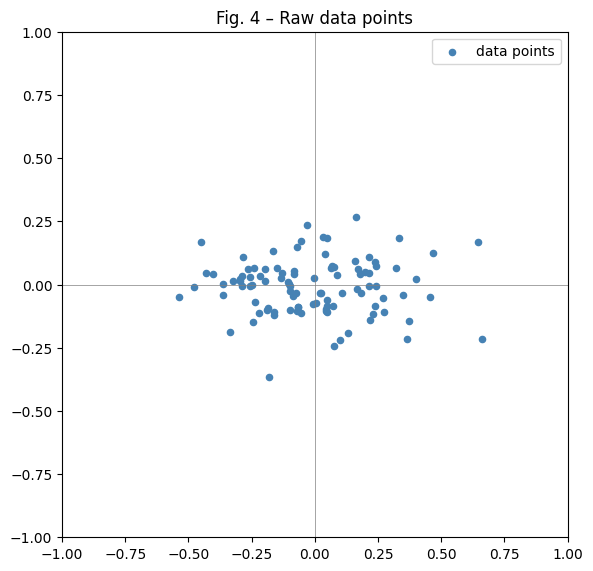

In [8]:
# ── Plot the raw data points ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_aspect('equal')          # keep the plot square so angles look correct
ax.set_title('Fig. 4 – Raw data points')
ax.scatter(x, y, s=20, color='steelblue', label='data points')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
# ── Step 1: center the data (subtract mean from each attribute) ──────────────
# PCA requires zero-mean data so that variance is measured around the origin
data_mean = np.mean(point_mat, axis=0)   # mean of x and mean of y
centered_data = point_mat - data_mean    # shape (N, 2)

# ── Step 2: compute the 2×2 covariance matrix ───────────────────────────────
# Formula: Cov = (centered.T @ centered) / N
cov_2d = (centered_data.T @ centered_data) / no_points

print("Data mean (x, y):", data_mean)
print("\nCovariance matrix of the 2D data:")
print(cov_2d)

Data mean (x, y): [-0.01068509 -0.00910449]

Covariance matrix of the 2D data:
[[ 0.0588285  -0.00038902]
 [-0.00038902  0.0118111 ]]


In [10]:
# ── Step 3 & 4: eigendecomposition + sort by descending eigenvalue ───────────
# np.linalg.eig returns:
#   eig_vals  – 1D array of eigenvalues
#   eig_vecs  – 2D array where COLUMN i is the eigenvector for eig_vals[i]
eig_vals, eig_vecs = np.linalg.eig(cov_2d)

# Sort from largest to smallest eigenvalue
sort_idx = np.argsort(eig_vals)[::-1]   # indices that would sort descending
eig_vals  = eig_vals[sort_idx]
eig_vecs  = eig_vecs[:, sort_idx]       # reorder columns to match

print("Eigenvalues (descending):", eig_vals)
print("Eigenvectors (columns):")
print(eig_vecs)

# The magnitude of variance explained by each principal component
# is the square root of its eigenvalue
print("\nStd-dev explained by each PC (sqrt of eigenvalue):")
for i, ev in enumerate(eig_vals):
    print(f"  PC{i+1}: {math.sqrt(abs(ev)):.6f}")

Eigenvalues (descending): [0.05883172 0.01180788]
Eigenvectors (columns):
[[ 0.99996578  0.00827305]
 [-0.00827305  0.99996578]]

Std-dev explained by each PC (sqrt of eigenvalue):
  PC1: 0.242553
  PC2: 0.108664


In [11]:
# ── Extract the two principal components ────────────────────────────────────
# pc1 = direction of GREATEST variance (largest eigenvalue)
# pc2 = direction of SECOND-GREATEST variance (orthogonal to pc1)
pc1 = eig_vecs[:, 0]   # first column
pc2 = eig_vecs[:, 1]   # second column

# Normalise to unit length so only direction matters
pc1 = pc1 / np.linalg.norm(pc1)
pc2 = pc2 / np.linalg.norm(pc2)

# Scale for plotting so the arrows are visible
scale = math.sqrt(eig_vals[0])   # length proportional to std-dev

print("PC1 (unit vector):", pc1)
print("PC2 (unit vector):", pc2)
print("PC1 · PC2 (should be ~0, i.e. orthogonal):", np.dot(pc1, pc2))

PC1 (unit vector): [ 0.99996578 -0.00827305]
PC2 (unit vector): [0.00827305 0.99996578]
PC1 · PC2 (should be ~0, i.e. orthogonal): 0.0


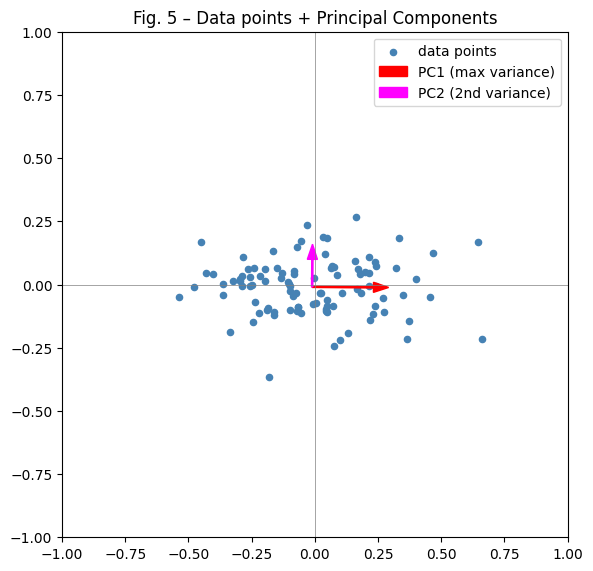

In [12]:
# ── Plot data + principal component arrows (Fig. 5) ──────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_aspect('equal')
ax.set_title('Fig. 5 – Data points + Principal Components')

# Scatter plot of original data
ax.scatter(x, y, s=20, color='steelblue', label='data points')

# Arrow for PC1 (red) – drawn from the data mean
ax.arrow(data_mean[0], data_mean[1],
         pc1[0] * scale, pc1[1] * scale,
         width=0.005, head_width=0.04,
         color='red', label='PC1 (max variance)')

# Arrow for PC2 (magenta) – orthogonal to PC1
scale2 = math.sqrt(eig_vals[1])
ax.arrow(data_mean[0], data_mean[1],
         pc2[0] * scale2, pc2[1] * scale2,
         width=0.005, head_width=0.04,
         color='magenta', label='PC2 (2nd variance)')

ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# ── Projection onto PC1 (2D → 1D) ───────────────────────────────────────────
# The projection formula (Fig. 7 in the lab):
#   x'_i = [ex, ey] · [xi, yi]  (dot product of the eigenvector with each point)
# This gives one scalar coordinate x'_i per point in 1D PC1-space.
#
# We work on CENTERED data so the eigenvectors pass through the origin.

proj_1d = centered_data @ pc1   # shape (N,)  – one scalar per point
print("First 5 projected (1D) coordinates:", proj_1d[:5])

First 5 projected (1D) coordinates: [-0.07080792 -0.32402582 -0.06521415  0.3305521   0.0030561 ]


In [14]:
# ── Inverse projection back to 2D (1D → 2D) ─────────────────────────────────
# The inverse formula (Fig. 8 in the lab):
#   [x''_i, y''_i] = x'_i * [ex, ey]
# We scale the eigenvector by the 1D coordinate to get a 2D point.
# We then ADD back the mean to un-center the data.

# proj_1d[:, np.newaxis] makes it shape (N, 1) so broadcasting works
reconstructed = proj_1d[:, np.newaxis] * pc1 + data_mean   # shape (N, 2)

print("First 5 original  2D points:", point_mat[:5])
print("First 5 reconstructed points:", reconstructed[:5])
print("\nNote: reconstructed ≠ original because 2D→1D→2D loses some information.")

First 5 original  2D points: [[-0.081091  0.03978 ]
 [-0.336192 -0.186784]
 [-0.076106 -0.033826]
 [ 0.320483  0.063983]
 [-0.008207 -0.078981]]
First 5 reconstructed points: [[-0.08149059 -0.00851869]
 [-0.33469982 -0.00642381]
 [-0.07589701 -0.00856497]
 [ 0.3198557  -0.01183916]
 [-0.0076291  -0.00912977]]

Note: reconstructed ≠ original because 2D→1D→2D loses some information.


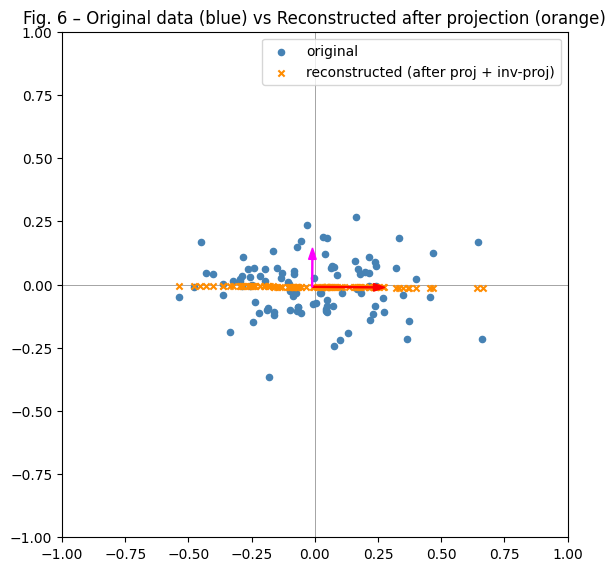

In [15]:
# ── Plot original + reconstructed points (Fig. 6) ───────────────────────────
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_aspect('equal')
ax.set_title('Fig. 6 – Original data (blue) vs Reconstructed after projection (orange)')

# Original data points
ax.scatter(x, y, s=20, color='steelblue', label='original', zorder=3)

# Reconstructed (projected then inverse-projected) points
ax.scatter(reconstructed[:, 0], reconstructed[:, 1],
           s=20, marker='x', color='darkorange',
           label='reconstructed (after proj + inv-proj)', zorder=3)

# PC1 and PC2 arrows for reference
ax.arrow(data_mean[0], data_mean[1],
         pc1[0] * scale, pc1[1] * scale,
         width=0.004, head_width=0.03, color='red', zorder=4)
ax.arrow(data_mean[0], data_mean[1],
         pc2[0] * scale2, pc2[1] * scale2,
         width=0.004, head_width=0.03, color='magenta', zorder=4)

ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.legend()
plt.tight_layout()
plt.show()

---
## Exercise 3 – Evaluate the Projection with R²

The **coefficient of determination R²** measures how well the reconstructed points match the originals.

$$R^2_x = 1 - \frac{\sum_{i=1}^{p}(x_i - x''_i)^2}{\sum_{i=1}^{p} x_i^2}$$

The same formula applies for y. R² ∈ [0, 1]; **values closer to 1 are better** (less information was lost).

In [16]:
# ── Compute R² for x and y separately ───────────────────────────────────────
x_orig = point_mat[:, 0]          # original x coordinates
y_orig = point_mat[:, 1]          # original y coordinates
x_rec  = reconstructed[:, 0]     # reconstructed x
y_rec  = reconstructed[:, 1]     # reconstructed y

# R² formula from Eq. 4 in the lab
R2_x = 1 - np.sum((x_orig - x_rec) ** 2) / np.sum(x_orig ** 2)
R2_y = 1 - np.sum((y_orig - y_rec) ** 2) / np.sum(y_orig ** 2)

print(f"R² for x: {R2_x:.6f}")
print(f"R² for y: {R2_y:.6f}")
print()
if R2_x > 0.9 and R2_y > 0.9:
    print("Both R² values are close to 1 → the PC1 projection preserves most of the data.")
elif R2_x > 0.7 or R2_y > 0.7:
    print("R² values are moderate → projection captures the main trend but loses some detail.")
else:
    print("R² values are low → significant information is lost in this projection.")

R² for x: 0.999986
R² for y: 0.007308

R² values are moderate → projection captures the main trend but loses some detail.


In [17]:
# ── Bonus: variance explained by each principal component ───────────────────
# This is a standard PCA metric: how much of the total variance does each PC capture?
total_variance = np.sum(eig_vals)
for i, ev in enumerate(eig_vals):
    pct = 100 * ev / total_variance
    print(f"PC{i+1} explains {pct:.2f}% of total variance  (eigenvalue = {ev:.6f})")

print(f"\n→ Keeping only PC1 retains {100 * eig_vals[0] / total_variance:.2f}% of the total variance.")

PC1 explains 83.28% of total variance  (eigenvalue = 0.058832)
PC2 explains 16.72% of total variance  (eigenvalue = 0.011808)

→ Keeping only PC1 retains 83.28% of the total variance.


---
## Summary

| Step | What we did |
|------|-------------|
| Ex 1 | Built the 3×3 covariance matrix of exam grades manually and interpreted variance/covariance values |
| Ex 2a | Loaded 100 2D points, computed the 2×2 covariance matrix, found eigenvectors = principal components |
| Ex 2b | Sorted PCs by eigenvalue; PC1 points in the direction of greatest data spread |
| Ex 2c | Projected all points onto PC1 (2D→1D), then inverse-projected back (1D→2D) |
| Ex 3 | Measured reconstruction quality with R²; values near 1 mean PC1 captures most of the data |